# COMP.SGN.120 Introduction to Audio and Speech Processing <br>
## Project work

In [19]:
# Import libraries
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

### Data selection <br>
Training: 90 samples each class, taken from 4 other users <br>
Validation: 14 samples each class, taken from 1 other user <br>
Testting: 36 samples each class, self-recorded

In [2]:
# Constant variable for file path
car_audio_directory_train = 'dataset/car_data_train'
tram_audio_directory_train = 'dataset/tram_data_train'
car_audio_directory_test = 'dataset/car_data_test'
tram_audio_directory_test = 'dataset/tram_data_test'
car_audio_directory_validation = 'dataset/car_data_validation'
tram_audio_directory_validation = 'dataset/tram_data_validation'

In [3]:
# Function for reading files, return the audio data as a list of tuples (y, sr).
def read_audio_files(directory_path):
    files = os.listdir(directory_path)
    wav_files = [f for f in files if f.endswith('.wav')]
    audio_data = []
    for file in wav_files:
        filepath = os.path.join(directory_path, file)
        y, sr = librosa.load(filepath, sr=None)
        audio_data.append((y, sr))

    return audio_data

In [4]:
# Functions for normalizing the audio
def volume_normalize(audios):
    return [(y / np.max(np.abs(y)), sr) for y, sr in audios]

def standardize_length(audios, duration):
    _, sr = audios[0]
    length = int(duration * sr)

    for y, sr in audios:
        if len(y) < length:
            y = np.pad(y, (0, length - len(y)), 'constant')
        elif len(y) > length:
            y = y[:length]

    return audios

In [5]:
# Function for extracting fearures from audio data, return the features as a list of lists.
def extract_features(audios):
    features = []
    for y, sr in audios:
        # Energy
        energy = np.sum(np.square(y))
        # Root-mean-square
        root_mean_square = np.sqrt(np.mean(np.square(y)))
        # Spectrogram
        spectrogram = np.abs(librosa.stft(y))
        # Log-spectrogram
        log_spectrogram = librosa.amplitude_to_db(spectrogram)
        # Mel-spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
        # Log-mel-spectrogram
        log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
        # Mel-frequency cepstral coefficients (MFCCs)
        mfccs = librosa.feature.mfcc(y=y, sr=sr)
        # Constant Q transform
        cqt = np.abs(librosa.core.cqt(y=y, sr=sr))

        features.append([energy, root_mean_square, spectrogram,
                         log_spectrogram, mel_spectrogram, log_mel_spectrogram,
                         mfccs, cqt])
        
    return features

In [6]:
# Function for plotting histograms of features
def plot_histograms(car_features, tram_features, plot_title):
    subplot_titles = ['Energy', 'Root-mean-square', 'Spectrogram', 'Log-spectrogram', 'Mel-spectrogram', 'Log-mel-spectrogram', 'MFCCs', 'CQT']
    plt.figure(figsize=(15, 8))
    plt.suptitle(plot_title)

    for i in range(len(subplot_titles)):
        plt.subplot(2, 4, i + 1)

        car_feature_values = []
        tram_feature_values = []

        for car_feature in car_features:
            if isinstance(car_feature[i], np.ndarray):
                car_feature_values.extend(car_feature[i].flatten())
            else:
                car_feature_values.append(car_feature[i])

        for tram_feature in tram_features:
            if isinstance(tram_feature[i], np.ndarray):
                tram_feature_values.extend(tram_feature[i].flatten())
            else:
                tram_feature_values.append(tram_feature[i])

        # Convert to numpy arrays for histogram plotting
        car_feature_values = np.array(car_feature_values)
        tram_feature_values = np.array(tram_feature_values)

        plt.hist(car_feature_values, bins=50, alpha=0.5, label='Car', color='blue')
        plt.hist(tram_feature_values, bins=50, alpha=0.5, label='Tram', color='red')
        plt.title(subplot_titles[i])
        plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to accommodate the suptitle
    plt.show()


In [7]:
# Read audio files
car_audio_train = read_audio_files(car_audio_directory_train)
tram_audio_train = read_audio_files(tram_audio_directory_train)
car_audio_validation = read_audio_files(car_audio_directory_validation)
tram_audio_validation = read_audio_files(tram_audio_directory_validation)
car_audio_test = read_audio_files(car_audio_directory_test)
tram_audio_test = read_audio_files(tram_audio_directory_test)

# Normalization. This includes normalizing volume and standardize the length of the audio.
car_audio_train = volume_normalize(car_audio_train)
tram_audio_train = volume_normalize(tram_audio_train)
car_audio_train = standardize_length(car_audio_train, 5)
tram_audio_train = standardize_length(tram_audio_train, 5)

car_audio_validation = volume_normalize(car_audio_validation)
tram_audio_validation = volume_normalize(tram_audio_validation)
car_audio_validation = standardize_length(car_audio_validation, 5)
tram_audio_validation = standardize_length(tram_audio_validation, 5)

car_audio_test = volume_normalize(car_audio_test)
tram_audio_test = volume_normalize(tram_audio_test)
car_audio_test = standardize_length(car_audio_test, 5)
tram_audio_test = standardize_length(tram_audio_test, 5)

# Extract features
car_features_train = extract_features(car_audio_train)
tram_features_train = extract_features(tram_audio_train)

car_features_validation = extract_features(car_audio_validation)
tram_features_validation = extract_features(tram_audio_validation)

car_features_test = extract_features(car_audio_test)
tram_features_test = extract_features(tram_audio_test)

In [8]:
print(len(car_audio_train))
print(len(tram_audio_train))
print(len(car_audio_validation))
print(len(tram_audio_validation))
print(len(car_audio_test))
print(len(tram_audio_test))


90
90
14
14
36
36


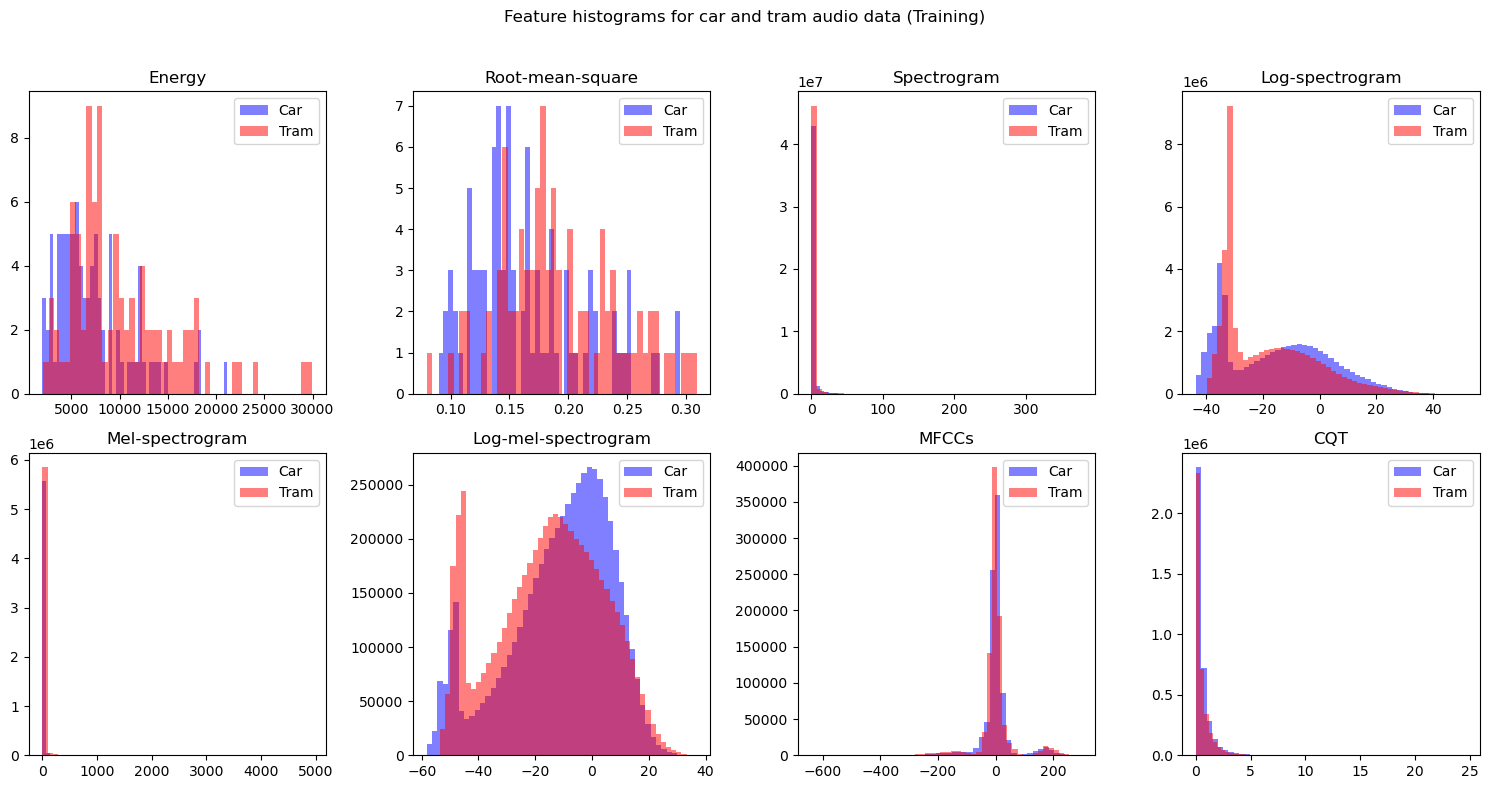

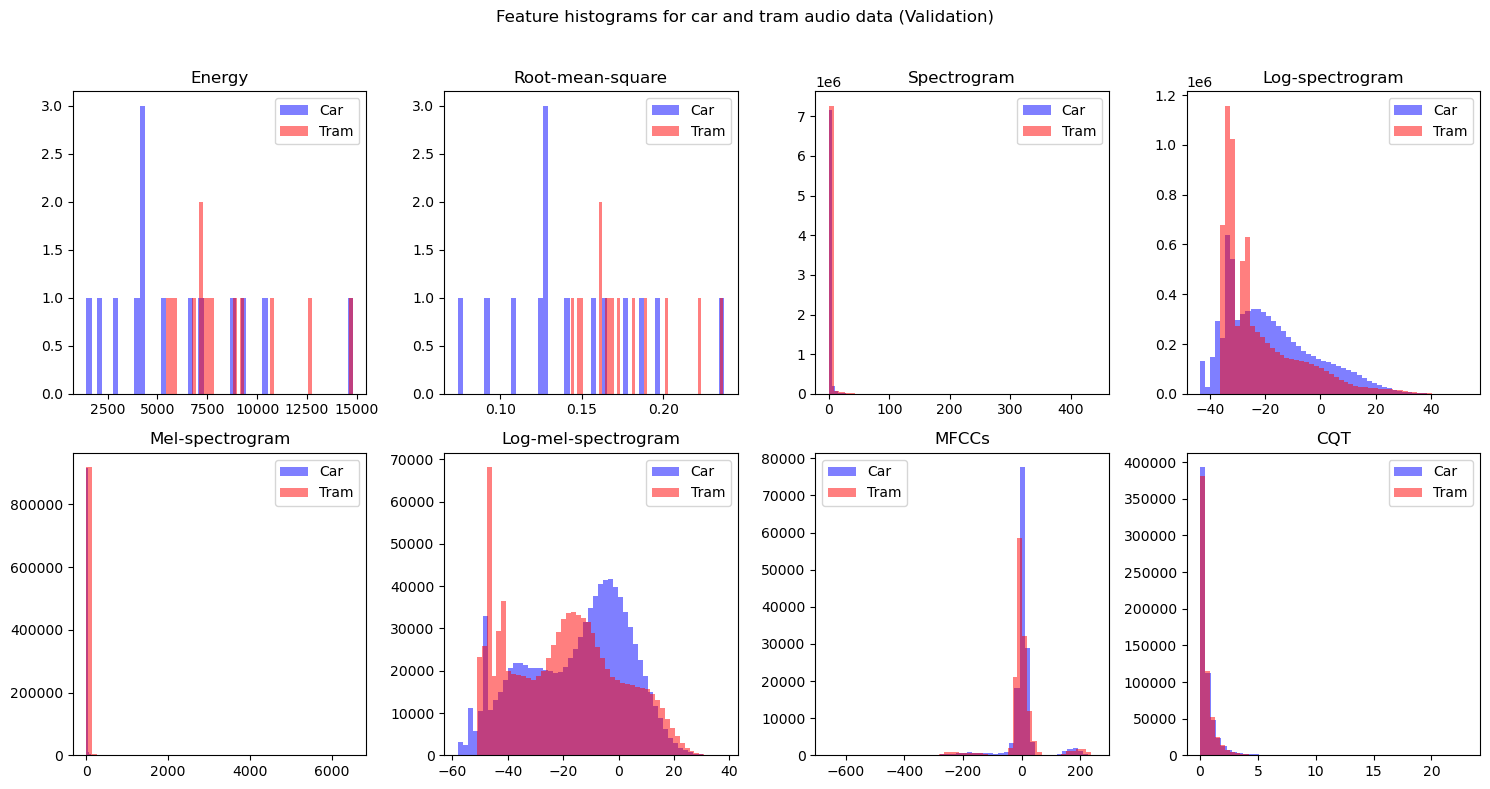

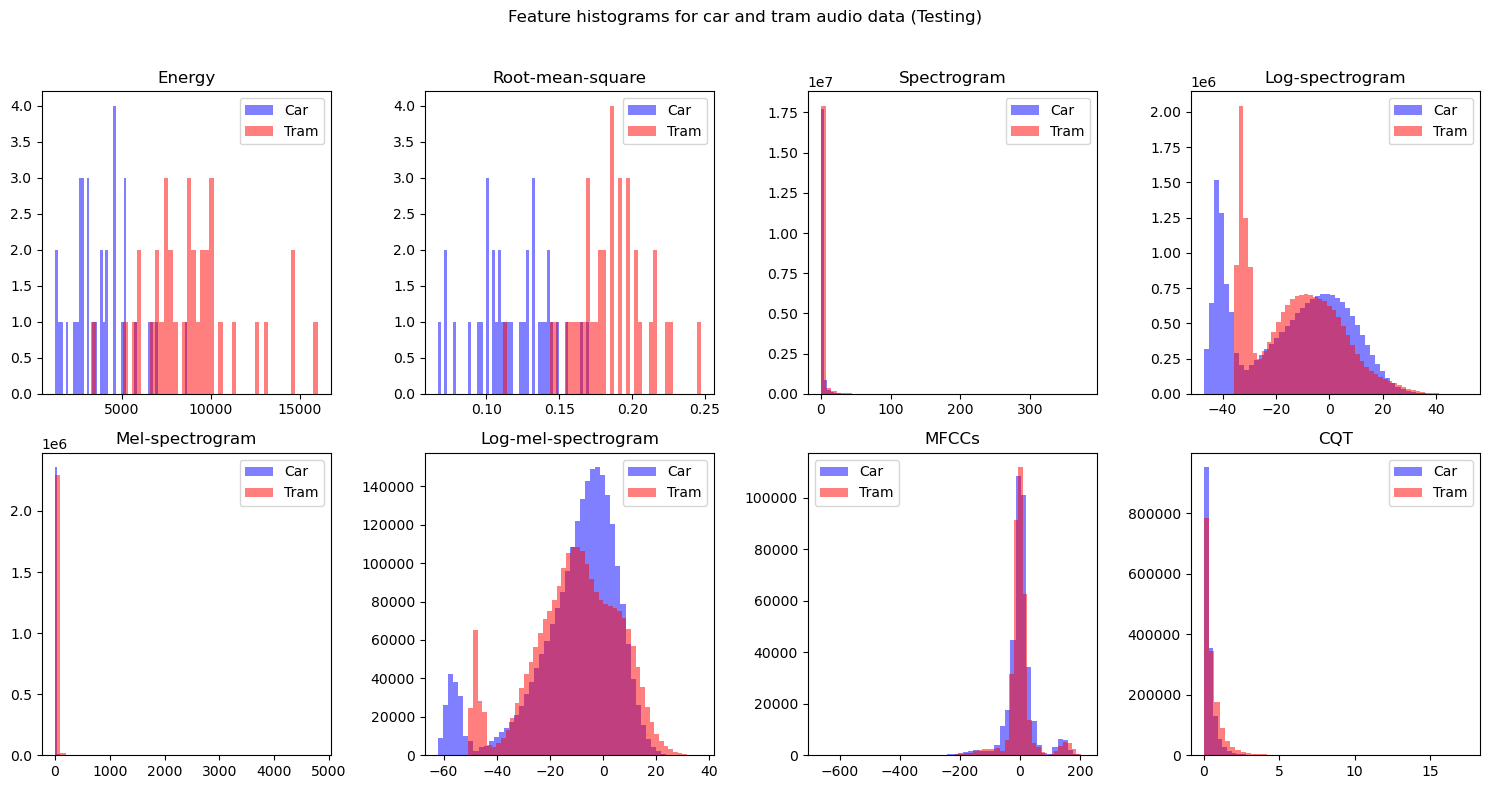

In [9]:
plot_histograms(car_features_train, tram_features_train, 'Feature histograms for car and tram audio data (Training)')
plot_histograms(car_features_validation, tram_features_validation, 'Feature histograms for car and tram audio data (Validation)')
plot_histograms(car_features_test, tram_features_test, 'Feature histograms for car and tram audio data (Testing)')

### Support vector machine (SVM) model

In [57]:
# Selecting features for classification
# The features selected are energy and root-mean-square

car_features_train = [[f[0], f[1]] for f in car_features_train]
tram_features_train = [[f[0], f[1]] for f in tram_features_train]
y_car = np.zeros(len(car_features_train))
y_tram = np.ones(len(tram_features_train))

X_train = np.concatenate((car_features_train, tram_features_train))
y_train = np.concatenate((y_car, y_tram))

car_features_validation = [[f[0], f[1]] for f in car_features_validation]
tram_features_validation = [[f[0], f[1]] for f in tram_features_validation]
y_car = np.zeros(len(car_features_validation))
y_tram = np.ones(len(tram_features_validation))

X_validation = np.concatenate((car_features_validation, tram_features_validation))
y_validation = np.concatenate((y_car, y_tram))

car_features_test = [[f[0], f[1]] for f in car_features_test]
tram_features_test = [[f[0], f[1]] for f in tram_features_test]
y_car = np.zeros(len(car_features_test))
y_tram = np.ones(len(tram_features_test))

X_test = np.concatenate((car_features_test, tram_features_test))
y_test = np.concatenate((y_car, y_tram))

In [16]:
# Standardizing among the two features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Define and train the SVM model
model = svm.SVC(kernel='rbf', C=1.0, random_state=19)
model.fit(X_train_scaled, y_train)

SVC(random_state=19)

In [51]:
# Predict the validation set
y_pred = model.predict(X_validation_scaled)

# Evaluate the model
accuracy_score_validation = accuracy_score(y_validation, y_pred)
precision_score_validation = precision_score(y_validation, y_pred)
recall_score_validation = recall_score(y_validation, y_pred)
print("Model ecaluation on validation set")
print('Validation accuracy:', accuracy_score_validation)
print('Validation precision:', precision_score_validation)
print('Validation recall:', recall_score_validation)

Model ecaluation on validation set
Validation accuracy: 0.6785714285714286
Validation precision: 0.6666666666666666
Validation recall: 0.7142857142857143


In [52]:
# Predict the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy_score_test = accuracy_score(y_test, y_pred)
precision_score_test = precision_score(y_test, y_pred)
recall_score_test = recall_score(y_test, y_pred)
print("Model ecaluation on test set")
print('Test accuracy:', accuracy_score_test)
print('Test precision:', precision_score_test)
print('Test recall:', recall_score_test)

Model ecaluation on test set
Test accuracy: 0.9027777777777778
Test precision: 0.9393939393939394
Test recall: 0.8611111111111112


/var/folders/_1/4_mw8y054rlg_56kgfr2qk3m0000gp/T/ipykernel_2766/3417446557.py:17: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm, marker='x', label='Test samples')


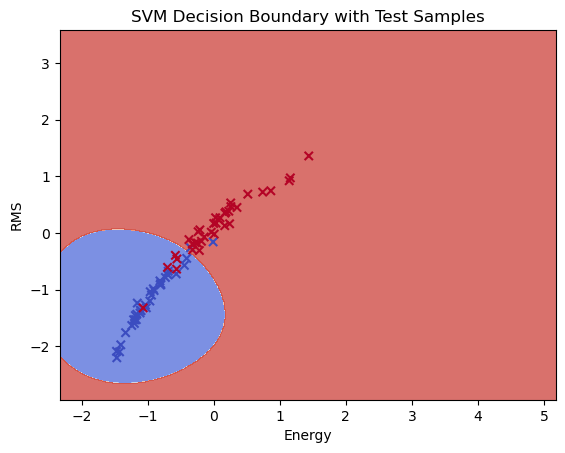

In [56]:
# Plot the decision boundary

# Create a grid of points covering the entire feature space
h = 0.01  # Step size in the mesh grid
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Use the trained SVM model to predict for each point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.75, cmap=plt.cm.coolwarm)

plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm, marker='x', label='Test samples')
plt.title("SVM Decision Boundary with Test Samples")
plt.xlabel("Energy")
plt.ylabel("RMS")
plt.show()